In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

### Q1: Assume \($y$\) is normally distributed. Write a script to get the mean and variance by maximising the likelihood.

In [2]:
mu = 2
sigma = 3
#Draw random samples from Gaussian distribution.
y = np.random.normal(mu,sigma,100000)

In [3]:
y

array([ 3.00794923,  0.73086544, -1.03259938, ...,  1.52728268,
       -0.10961879,  1.90421236])

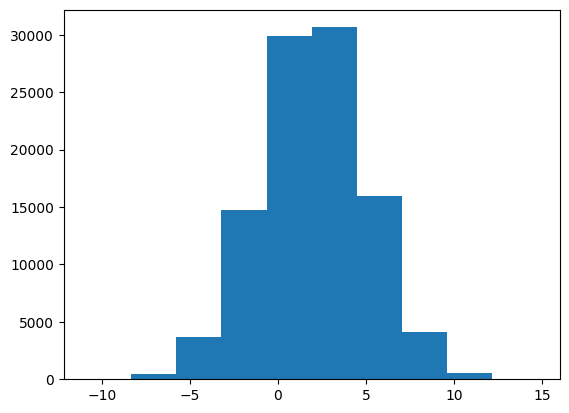

In [4]:
plt.hist(y)
plt.show()

### Log-Likelihood for \($n$\) Independent Observations


For \($n$\) independent observations \( $y_1, y_2, \dots, y_n$ \), the log-likelihood function is the logarithm of the likelihood function. The likelihood function for independent observations is the product of the individual probabilities:

$$
L(\mu, \sigma^2) = -\frac{n}{2} \log(2 \pi \sigma^2) - \frac{1}{2 \sigma^2} \sum_{i=1}^{n} (y_i - \mu)^2
$$

Tips: Why use log-likelihood?  
1.Simplify product to sum.  
2.Logarithm is monotonically increasing.  

<ins>Find breakdown on ELE (Written_notes:MLE-Gaussian).<ins>

In [5]:
#define a function to be minimized
def likelihood(theta,*args):
  # theta: unknow parameters to be estimated
  # *args: dataset
  n = len(y)
  mu = theta[0]
  sigma = theta[1]
  L = -(n/2)*np.log(2*np.pi)-(n/2)*np.log(sigma**2)-(1/(2*sigma**2))*np.sum((y-mu)**2)
  return -L
  # return: likelihood value


In [6]:
#use Scipy.minimize() to estimate unknown parameters by maximizing the likelihood
x0 = [1,1]
results = minimize(likelihood, x0, args=(y), bounds=None, method="L-BFGS-B")

In [7]:
#print result
print(results.x)

[2.00930045 3.00137758]


### Direct Method

1. **Mean (  $\mu$  )**: The maximum likelihood estimate for the mean is the sample mean:
   $$
   \mu = \frac{1}{n} \sum_{i=1}^{n} y_i
   $$

2. **Variance (  $\sigma^2$  )**: The maximum likelihood estimate for the variance is:
   $$
   \sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - \mu)^2
   $$

Where:
- \( $y_i$ \) represents the observed data,
- \( $n$ \) is the number of observations,
- \( $\mu$ \) is the estimated mean,
- \( $\sigma^2$ \) is the estimated variance.

<ins>Find breakdown on ELE (Written_notes:MLE-Gaussian).<ins>

In [8]:
# Direct method

# 1. Calculate the mean (μ)
n = len(y)  # Number of data points
mu = sum(y) / n  # Mean (μ)

# 2. Calculate the variance (σ^2)
sigma = np.sqrt(sum((yi - mu) ** 2 for yi in y) / n)  # Variance (σ^2)

# Print the results
print(f"Maximum Likelihood Estimate for μ: {mu}")
print(f"Maximum Likelihood Estimate for σ: {sigma}")

Maximum Likelihood Estimate for μ: 2.0092991833113243
Maximum Likelihood Estimate for σ: 3.0013781988128674


### Q2: Horse Kick.
1. Figure out likelihood of Poisson Distribution.
2. Load the data.
3. Define likelihood function.
4. Use Scipy to optimize the likelihood function.

In [ ]:
"""
If using Clolab...
Connect with Google drive
1. Upload your files to Google drive.
2. Run the code below.
"""

from google.colab import drive
drive.mount('/drive') #Mount your Google Drive to the directory /drive

#TODO Load your data